### Mounting drive and createing folders for checkpoints and artifacts

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/DeepfakeAudio'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, 'checkpoints'),exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, 'artifacts'), exist_ok=True)

print(f"Project directory ready: {PROJECT_DIR}")
print(os.listdir(PROJECT_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory ready: /content/drive/MyDrive/DeepfakeAudio
['checkpoints', 'artifacts']


In [4]:
!pip install -q torchaudio librosa kaggle scikit-learn matplotlib

import torch, torchaudio, librosa, sklearn, numpy as np, matplotlib, random
print(f"torch: {torch.__version__}")
print(f"torchaudio: {torchaudio.__version__}")
print(f"CUDA available: {torch.cuda.is_available}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"}")

torch: 2.11.0+cpu
torchaudio: 2.11.0+cpu
CUDA available: <function is_available at 0x7cd37925fc40>
Device: CPU only


In [5]:
SEED = 42

def set_seed(seed=SEED):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

set_seed()

### Getting Kaggle Dataset

In [6]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [7]:
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [9]:
DATA_DIR = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)

!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset -p {DATA_DIR}
!unzip -q {DATA_DIR}/the-fake-or-real-dataset.zip -d {DATA_DIR}

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
100% 16.0G/16.0G [02:59<00:00, 95.7MB/s]



In [11]:
TRAIN_DIR = os.path.join(DATA_DIR, 'for-norm', 'for-norm', 'training')
REAL_DIR = os.path.join(TRAIN_DIR, 'real')
FAKE_DIR = os.path.join(TRAIN_DIR, 'fake')

real_files = [os.path.join(REAL_DIR, f) for f in os.listdir(REAL_DIR)]
fake_files = [os.path.join(FAKE_DIR, f) for f in os.listdir(FAKE_DIR)]

print(f"Real: {len(real_files)}")
print(f"Fake: {len(fake_files)}")
print(f"Total: {len(real_files)+len(fake_files)}")

print("Sample real:", real_files[0])
print("Sample fake:", fake_files[0])

Real: 26941
Fake: 26927
Total: 53868
Sample real: /content/data/for-norm/for-norm/training/real/file828.wav_16k.wav_norm.wav_mono.wav_silence.wav
Sample fake: /content/data/for-norm/for-norm/training/fake/file4622.wav_16k.wav_norm.wav_mono.wav_silence.wav


### EDA

In [12]:
def quick_probe(path):
  wav, sr = torchaudio.load(path)
  return wav.shape, sr, wav.shape[1]/sr

for p in random.sample(real_files, 3) + random.sample(fake_files, 3):
  shape, sr, dur = quick_probe(p)
  print(f"{os.path.basename(p)[:30]:32} shape={shape} sr={sr} dur={dur:.2f}s")

file2818.wav_16k.wav_norm.wav_   shape=torch.Size([1, 54882]) sr=16000 dur=3.43s
file30319.wav_16k.wav_norm.wav   shape=torch.Size([1, 62444]) sr=16000 dur=3.90s
file9017.wav_16k.wav_norm.wav_   shape=torch.Size([1, 110138]) sr=16000 dur=6.88s
file27911.mp3.wav_16k.wav_norm   shape=torch.Size([1, 11240]) sr=16000 dur=0.70s
file26630.mp3.wav_16k.wav_norm   shape=torch.Size([1, 54396]) sr=16000 dur=3.40s
file8714.mp3.wav_16k.wav_norm.   shape=torch.Size([1, 26767]) sr=16000 dur=1.67s


600
min. duration: 0.38s
max. duration: 10.28s
mean duration: 3.17s
median duration: 2.42s


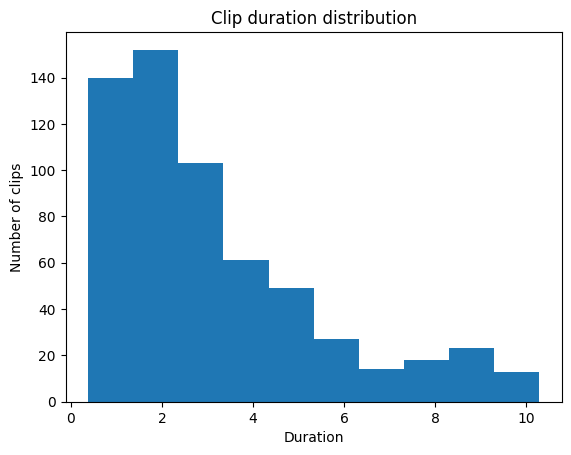

In [19]:
import matplotlib.pyplot as plt

durations = []
for p in random.sample(real_files, 300) + random.sample(fake_files, 300):
  try:
    dur = librosa.get_duration(path=p)
    durations.append(dur)
  except Exception as e:
    print(f"Bad file:", p, e)

durations = np.array(durations)
print(len(durations))
print(f"min. duration: {durations.min():.2f}s")
print(f"max. duration: {durations.max():.2f}s")
print(f"mean duration: {durations.mean():.2f}s")
print(f"median duration: {np.median(durations):.2f}s")

plt.hist(durations)
plt.title('Clip duration distribution')
plt.xlabel('Duration')
plt.ylabel('Number of clips')
plt.show()

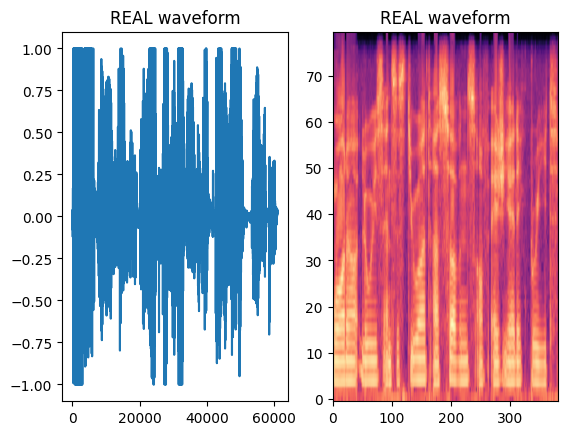

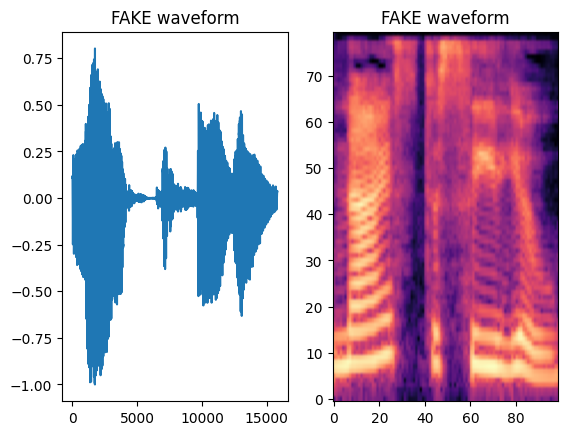

In [22]:
def show_audio(path, title):
  wav, sr = torchaudio.load(path)
  wav = wav.mean(0)
  mel = torchaudio.transforms.MelSpectrogram(sample_rate=sr, n_fft=512,hop_length=160,n_mels=80)(wav.unsqueeze(0))
  logmel = torch.log(mel+1e-6).squeeze(0)

  fig, ax = plt.subplots(1,2)
  ax[0].plot(wav.numpy())
  ax[0].set_title(f"{title} waveform")

  ax[1].imshow(logmel.numpy(),origin='lower',aspect='auto',cmap='magma')
  ax[1].set_title(f"{title} waveform")

  plt.show()

show_audio(random.choice(real_files), 'REAL')
show_audio(random.choice(fake_files), 'FAKE')